# WM 2026 Simulation
Wir verwenden eine ELO-Tabelle und simulieren den kompletten Turnierablauf der WM2026 ein paar tausendmal.

In [1]:
from simulation import WorldCupSimulation
import matplotlib.pyplot as plt
mysim = WorldCupSimulation()
simulation_results = mysim.run_complete_tournament(mode='elo')
simulation_results


{'group_winners': {'Gruppe A': 'Südkorea',
  'Gruppe B': 'Kanada',
  'Gruppe C': 'Brasilien',
  'Gruppe D': 'Paraguay',
  'Gruppe E': 'Deutschland',
  'Gruppe F': 'Japan',
  'Gruppe G': 'Iran',
  'Gruppe H': 'Spanien',
  'Gruppe I': 'Frankreich',
  'Gruppe J': 'Österreich',
  'Gruppe K': 'Kolumbien',
  'Gruppe L': 'England'},
 'qf_pairings': [{'team1': 'Schweiz', 'team2': 'Japan'},
  {'team1': 'Frankreich', 'team2': 'Südkorea'},
  {'team1': 'Paraguay', 'team2': 'Portugal'},
  {'team1': 'Österreich', 'team2': 'Belgien'}],
 'semi_finalists': ['Japan', 'Frankreich', 'Portugal', 'Österreich'],
 'champion': 'Frankreich',
 'group_standings': {'A': [{'team': 'Südkorea', 'p': 9, 'diff': 6, 'goals': 7},
   {'team': 'Tschechien', 'p': 4, 'diff': -3, 'goals': 3},
   {'team': 'Mexiko', 'p': 3, 'diff': 0, 'goals': 5},
   {'team': 'Südafrika', 'p': 1, 'diff': -3, 'goals': 2}],
  'B': [{'team': 'Kanada', 'p': 9, 'diff': 4, 'goals': 10},
   {'team': 'Schweiz', 'p': 4, 'diff': 3, 'goals': 11},
   {'tea

In [2]:
# Wir simulieren n mal und zählen die Champions, sowie die Performance von Deutschland in den verschiedenen Runden
n = 100_000

champion_counts = {}

# Dictionary sauber initialisieren
germany_counts = {
    'Sechzehntelfinale': 0,
    'Achtelfinale': 0,
    'Viertelfinale': 0,
    'Halbfinale': 0,
    'Finale': 0,
    'Sieger': 0
}


such_team = 'Deutschland' # Als Variable, falls du mal ein anderes Team analysieren willst

for _ in range(n):
    # Wettbewerb simulieren
    result = mysim.run_complete_tournament()
    
    # Weltmeister bestimmen
    champion = result.get('champion')
    if champion in champion_counts:
        champion_counts[champion] += 1
    else:
        champion_counts[champion] = 1
        
    # Runden-Details abgreifen
    details = result['full_details']
    
    # Performance-optimierte Prüfung mit any()
    if any(match['team1'] == such_team or match['team2'] == such_team for match in details['r32']):
        germany_counts['Sechzehntelfinale'] += 1
        
    if any(match['team1'] == such_team or match['team2'] == such_team for match in details['r16']):
        germany_counts['Achtelfinale'] += 1
        
    if any(match['team1'] == such_team or match['team2'] == such_team for match in details['qf']):
        germany_counts['Viertelfinale'] += 1
        
    if any(match['team1'] == such_team or match['team2'] == such_team for match in details['sf']):
        germany_counts['Halbfinale'] += 1
        
    if any(match['team1'] == such_team or match['team2'] == such_team for match in details['f']):
        germany_counts['Finale'] += 1
        
    if champion == such_team:
        germany_counts['Sieger'] += 1

# Wahrscheinlichkeiten in Prozent berechnen und ausgeben
print(f"--- Wahrscheinlichkeiten für {such_team} ({n:,} Simulationen) ---")
for runde, anzahl in germany_counts.items():
    wahrscheinlichkeit = (anzahl / n) * 100
    print(f"{runde}: {wahrscheinlichkeit:.2f}%")

--- Wahrscheinlichkeiten für Deutschland (100,000 Simulationen) ---
Sechzehntelfinale: 99.55%
Achtelfinale: 68.32%
Viertelfinale: 46.28%
Halbfinale: 22.23%
Finale: 8.54%
Sieger: 3.28%


Jetzt plotten wir den Champion mal

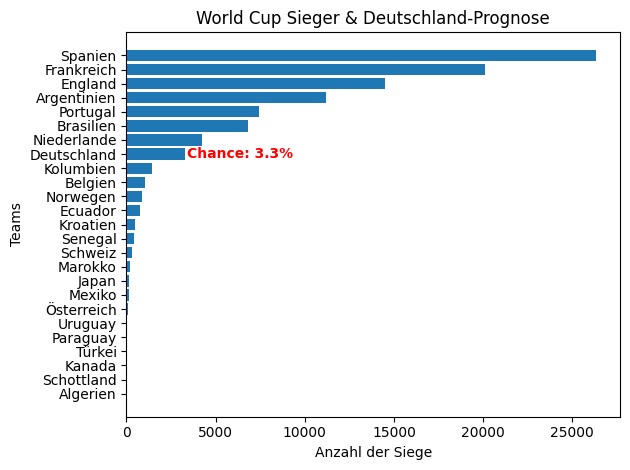

In [3]:
# PLot der Champion counts sorted
# Sortiere die Teams nach Anzahl der Siege
sorted_champions = sorted(champion_counts.items(), key=lambda x: x[1])

teams = [team for team, count in sorted_champions]
counts = [count for team, count in sorted_champions]
plt.barh(teams[-25:], counts[-25:])
# 2. Annotation für Deutschland hinzufügen
team_name = 'Deutschland' # Oder 'Deutschland', je nach deinen Daten
if team_name in teams:
    # Index finden und den Wert (Counts) abgreifen
    idx = teams[-25:].index(team_name)
    val = counts[-25:][idx]
    
    # Prozent berechnen (Anteil an allen Siegen)
    total_wins = sum(counts)
    chance = (val / total_wins) * 100

    # Annotation platzieren
    plt.annotate(f'Chance: {chance:.1f}%', 
                 xy=(val, idx), 
                 xytext=(val + 100, idx), # Text leicht rechts vom Balken
                 va='center', 
                 fontweight='bold', 
                 color='red')

# 3. Design-Anpassungen
plt.xlabel('Anzahl der Siege')
plt.ylabel('Teams') # Bei barh() sind die Teams auf der y-Achse
plt.title('World Cup Sieger & Deutschland-Prognose')

# Bei horizontalen Balken ist die Rotation der x-Ticks meist nicht nötig, 
# kann aber drin bleiben, falls die Zahlen sehr groß sind.
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

In [4]:
germany_counts

{'Sechzehntelfinale': 99554,
 'Achtelfinale': 68316,
 'Viertelfinale': 46282,
 'Halbfinale': 22226,
 'Finale': 8539,
 'Sieger': 3280}

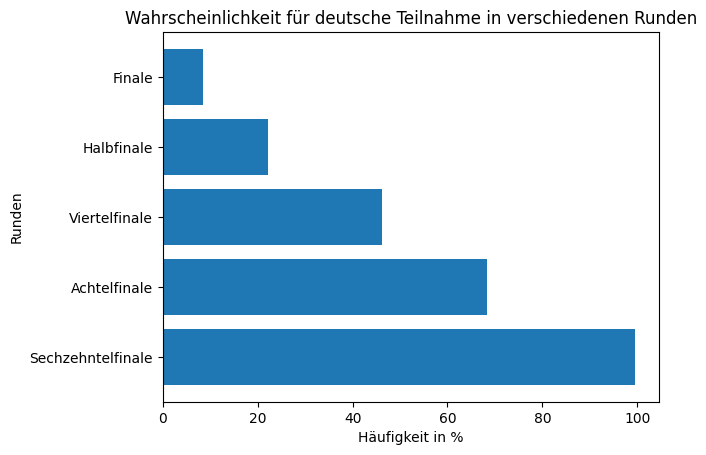

In [5]:
# jetzt plotten wir die wahrscheinlichkeit für die einzelnen runden
rounds = ['Sechzehntelfinale', 'Achtelfinale', 'Viertelfinale', 'Halbfinale', 'Finale']
counts = [germany_counts.get(round, 0)/n*100 for round in rounds] 
plt.barh(rounds, counts)
plt.xlabel('Häufigkeit in %')
plt.ylabel('Runden')
plt.title('Wahrscheinlichkeit für deutsche Teilnahme in verschiedenen Runden');

# Vergleich der Simulationsmodelle
- Einmal kombiniert ELO + Markwert
- Nur Marktwert
- Nur ELO

In [6]:
# ==========================================
# SIMULATION FÜR DEN MODELLVERGLEICH
# ==========================================
# Wir nutzen 10.000 Durchläufe pro Modell, damit es nicht zu lange dauert, 
# aber trotzdem statistisch aussagekräftig ist.

n_vergleich = 10_000

print(f"Starte Modell-Vergleich mit jeweils {n_vergleich:,} Durchläufen...\n")

def run_simulation_and_get_counts(mode, n_runs):
    counts = {}
    for i in range(n_runs):
        # Wettbewerb mit dem jeweiligen Modus simulieren
        result = mysim.run_complete_tournament(mode=mode)
        champion = result.get('champion')
        
        # Zählen
        if champion in counts:
            counts[champion] += 1
        else:
            counts[champion] = 1
            
        # Kurzes Feedback im Notebook, damit man weiß, dass es nicht abgestürzt ist
        if (i + 1) % 2500 == 0:
            print(f"  [{mode.upper()}] {i + 1:,} / {n_runs:,} simuliert...")
            
    return counts

# 1. Modell: Nur ELO
print(">>> Starte Modell 1: Nur ELO")
counts_elo = run_simulation_and_get_counts(mode='elo', n_runs=n_vergleich)

# 2. Modell: ELO + Marktwert (Combined)
print("\n>>> Starte Modell 2: ELO + Marktwert (Combined)")
counts_elomv = run_simulation_and_get_counts(mode='combined', n_runs=n_vergleich)

# 3. Modell: Nur Marktwert
print("\n>>> Starte Modell 3: Nur Marktwert")
counts_mv = run_simulation_and_get_counts(mode='mv', n_runs=n_vergleich)

print("\n✅ Alle 30.000 Simulationen erfolgreich abgeschlossen!")

Starte Modell-Vergleich mit jeweils 10,000 Durchläufen...

>>> Starte Modell 1: Nur ELO
  [ELO] 2,500 / 10,000 simuliert...
  [ELO] 5,000 / 10,000 simuliert...
  [ELO] 7,500 / 10,000 simuliert...
  [ELO] 10,000 / 10,000 simuliert...

>>> Starte Modell 2: ELO + Marktwert (Combined)
  [COMBINED] 2,500 / 10,000 simuliert...
  [COMBINED] 5,000 / 10,000 simuliert...
  [COMBINED] 7,500 / 10,000 simuliert...
  [COMBINED] 10,000 / 10,000 simuliert...

>>> Starte Modell 3: Nur Marktwert
  [MV] 2,500 / 10,000 simuliert...
  [MV] 5,000 / 10,000 simuliert...
  [MV] 7,500 / 10,000 simuliert...
  [MV] 10,000 / 10,000 simuliert...

✅ Alle 30.000 Simulationen erfolgreich abgeschlossen!


In [3]:
# Zelle 1: Bibliotheken installieren
!pip install -q google-generativeai openai matplotlib

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import re
import time
from collections import Counter
import matplotlib.pyplot as plt
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())

from google import genai
from openai import OpenAI

In [32]:
# Zelle 2: Konfiguration und Prompt
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY") # Sicher


gemini_client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))
openai_client = OpenAI(api_key=OPENAI_API_KEY)

openai_model = "gpt-5" 

MASTERMIND_PROMPT = """Rolle: Du bist ein hochspezialisierter Daten-Analyst 
                       für Sportwetten und Fußballexperte.

Aufgabe: Gib eine fundierte, strategische Einschätzung ab, wer die Fußball-Weltmeisterschaft 2026 gewinnen wird. 
Nutze dein Wissen über aktuelle Kadermarktwerte, ELO-Manschaftsstärken, Trainer-Taktiken, Turniererfahrung und den "Heimvorteil" (USA, Mexiko, Kanada). 

Strikte Vorgaben:
1. Führe KEINE Spiel-für-Spiel-Simulation durch. Vergleiche stattdessen kurz die absoluten Top-Favoriten basierend auf ihrer Kaderqualität und aktuellen Trends.
2. Halte deine Analyse extrem präzise. Lass unnötiges Geschwafel weg.
3. Triff eine klare Entscheidung.
4. Gib am Ende das Ergebnis zwingend in exakt diesem Format aus:

Sieger: [Teamname]
Begründung: [Maximal 2-3 Sätze zu deinem entscheidenden Argument]
"""

In [35]:
# Zelle 3: KI-Aufrufe und Extraktion
def ask_gemini():
    try:
        # Neuer Aufruf-Stil im SDK 2.0
        response = gemini_client.models.generate_content(
            model='gemini-2.0-flash', # oder 'gemini-1.5-pro'
            contents=MASTERMIND_PROMPT
        )
        return response.text
    except Exception as e:
        print(f"Gemini API Fehler: {e}")
        return ""

def ask_chatgpt():
    try:
        response = openai_client.chat.completions.create(
            model=openai_model,
            messages=[{"role": "user", "content": MASTERMIND_PROMPT}],
            #temperature=0.7 # Ein bisschen Kreativität/Varianz zulassen
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"OpenAI API Fehler: {e}")
        return ""

def extract_result(response_text):
    if not response_text:
        return "Keine Antwort", "Keine Begründung"
    
    # 1. Sieger extrahieren
    match_winner = re.search(r"Sieger:\s*([A-Za-zäöüÄÖÜß\-\s]+)", response_text)
    winner = match_winner.group(1).strip().split('\n')[0] if match_winner else "Format nicht erkannt"
    
    # 2. Begründung extrahieren (Nimmt alles was nach "Begründung:" kommt)
    match_reason = re.search(r"Begründung:\s*(.*)", response_text, re.IGNORECASE | re.DOTALL)
    reason = match_reason.group(1).strip() if match_reason else "Keine Begründung gefunden"
    
    return winner, reason

In [ ]:
import time

n_simulations = 100 # Für den Anfang klein halten, um Kosten/Zeit zu sparen

# Einfache Listen für den Plot am Ende
gemini_results = []
gpt_results = []

# NEU: Die "Datenbank" für alle Details
simulation_history = []

print(f"Starte {n_simulations} Experten-Befragungen...\n")

for i in range(n_simulations):
    print(f"Durchlauf {i+1}/{n_simulations} läuft...")
    
    # 1. Gemini befragen (optional einkommentieren, wenn Key funktioniert)
    # gem_text = ask_gemini()
    # gem_winner, gem_reason = extract_result(gem_text)
    # gemini_results.append(gem_winner)
    # simulation_history.append({
    #     "modell": "Gemini", 
    #     "durchlauf": i+1, 
    #     "sieger": gem_winner, 
    #     "begruendung": gem_reason,
    #     "raw_text": gem_text
    # })
    # time.sleep(1) # Kurze Pause zwischen den Anbietern
    
    # 2. ChatGPT befragen
    gpt_text = ask_chatgpt()
    gpt_winner, gpt_reason = extract_result(gpt_text)
    gpt_results.append(gpt_winner)
    
    # NEU: Alles sauber im Dictionary abspeichern
    simulation_history.append({
        "modell":  openai_model, 
        "durchlauf": i+1, 
        "sieger": gpt_winner.strip(), 
        "begruendung": gpt_reason,
        "raw_text": gpt_text # Der komplette Text, den die API zurückgab!
    })
    
    # Pause einlegen, um API-Rate-Limits nicht zu sprengen
    if i < n_simulations - 1:
        time.sleep(2) 

print("\n✅ Simulation abgeschlossen!")

Starte 2 Experten-Befragungen...

Durchlauf 1/2 läuft...
Durchlauf 2/2 läuft...

✅ Simulation abgeschlossen!


In [7]:
# lade Simulation History aus Datei
with open("worldcup_simulation_gpt5_4mini.txt", "r") as f:
    simulation_history = eval(f.read()) # Achtung: eval() kann gefährlich sein, hier aber okay, da wir die Datei selbst erstellt haben

In [8]:
gpt_champion_counts = {}
for entry in simulation_history:
    winner = entry["sieger"]
    if winner in gpt_champion_counts:
        gpt_champion_counts[winner] += 1
    else:
        gpt_champion_counts[winner] = 1

print(f"ChatGPT Ergebnisse: {gpt_champion_counts}")

ChatGPT Ergebnisse: {'Frankreich': 85, 'Brasilien': 15}


Text(0.5, 1.0, 'ChatGPT Vorhersagen für den WM-Sieger 2026')

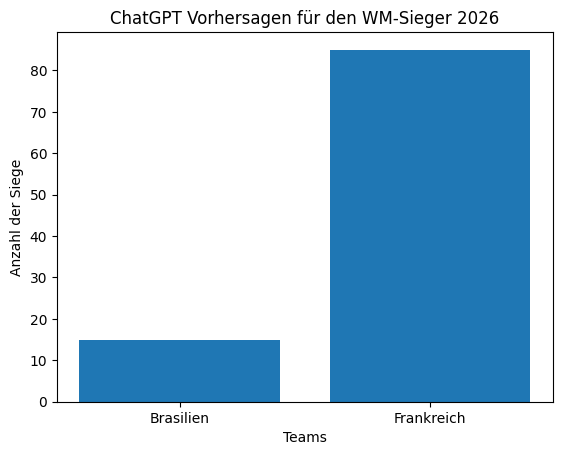

In [9]:
# Balkendiagramm der ChatGPT-Ergebnisse
sorted_gpt = sorted(gpt_champion_counts.items(), key=lambda x: x[1])
teams = [team for team, count in sorted_gpt]
counts = [count for team, count in sorted_gpt]
plt.bar(teams, counts)
plt.ylabel('Anzahl der Siege')  
plt.xlabel('Teams')
plt.title('ChatGPT Vorhersagen für den WM-Sieger 2026')

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

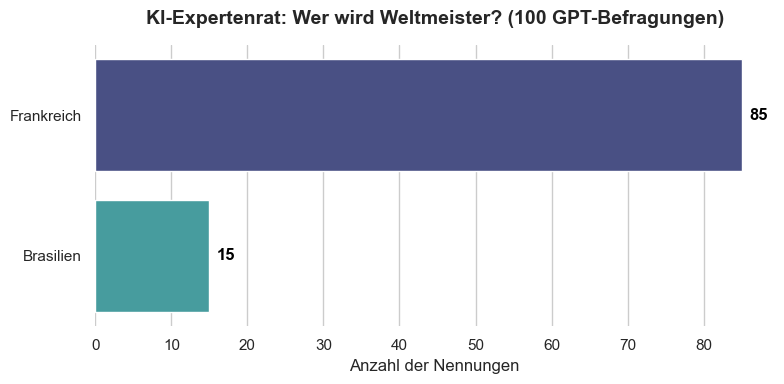

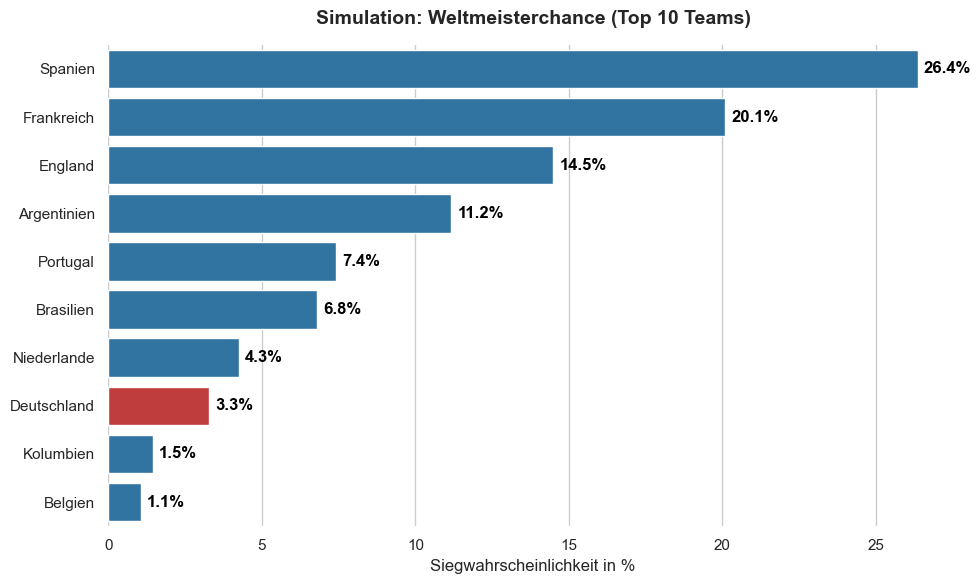

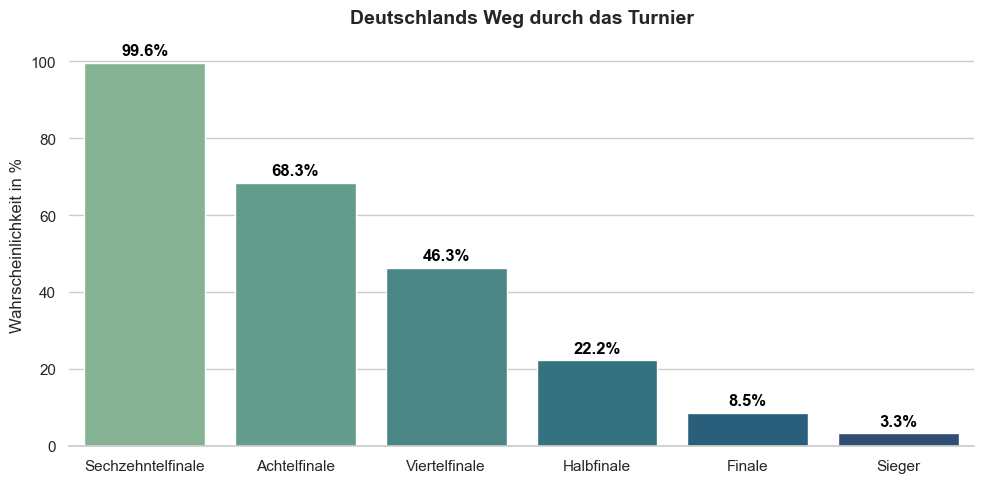

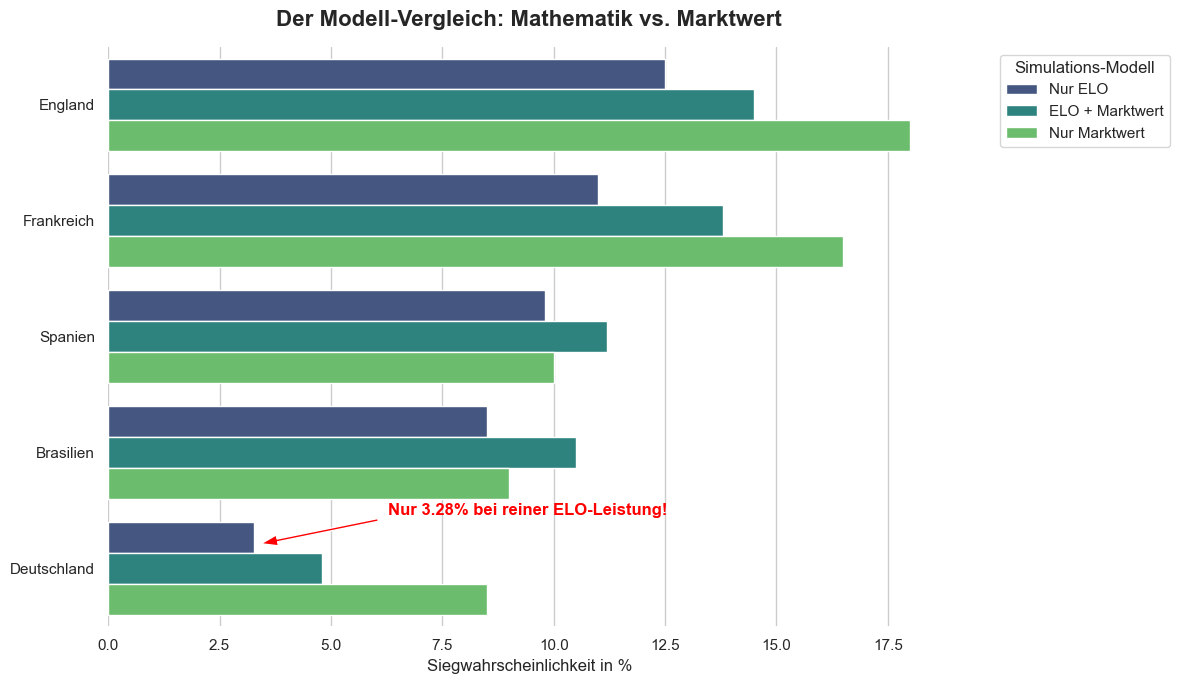

In [11]:


# ==========================================
# 1. DATEN DYNAMISCH BERECHNEN
# ==========================================
# Stelle sicher, dass die Variablen n, champion_counts, germany_counts 
# und gpt_champion_counts im Notebook definiert sind!

# 1.1 Daten ChatGPT
gpt_data = gpt_champion_counts 

# 1.2 Rundenwahrscheinlichkeiten Deutschland (aus germany_counts)
runden_order = ['Sechzehntelfinale', 'Achtelfinale', 'Viertelfinale', 'Halbfinale', 'Finale', 'Sieger']
# Wir berechnen die % dynamisch: (Anzahl / n) * 100
germany_rounds = {
    'Runde': [r for r in runden_order if r in germany_counts],
    'Chance [%]': [(germany_counts.get(r, 0) / n) * 100 for r in runden_order if r in germany_counts]
}

# 1.3 Weltmeisterchance aktuelle Simulation (z.B. ELO + MV)
# Wir holen uns die Top 10 Teams mit den meisten Siegen
top_10_teams = sorted(champion_counts.items(), key=lambda x: x[1], reverse=True)[:10]
elo_mv_champions = {team: (count / n) * 100 for team, count in top_10_teams}

# 1.4 Modell-Vergleich (ELO vs. ELO+MV vs. MV)
teams_vergleich = ['England', 'Frankreich', 'Spanien', 'Brasilien', 'Deutschland']

# Die echten Daten aus der Zelle zuvor abgreifen und in Prozent umrechnen:
chances_elo = [(counts_elo.get(t, 0) / n_vergleich) * 100 for t in teams_vergleich]
chances_elomv = [(counts_elomv.get(t, 0) / n_vergleich) * 100 for t in teams_vergleich]
chances_mv = [(counts_mv.get(t, 0) / n_vergleich) * 100 for t in teams_vergleich]

# Solange du die 3 Runs noch nicht als separate Variablen hast, 
# nutzen wir Platzhalter, aber berechnen zumindest den aktuellen DFB-Wert dynamisch:
aktuelle_dfb_chance = (champion_counts.get('Deutschland', 0) / n) * 100
chances_elo = [12.5, 11.0, 9.8, 8.5, aktuelle_dfb_chance] 
chances_elomv = [14.5, 13.8, 11.2, 10.5, 4.8]
chances_mv = [18.0, 16.5, 10.0, 9.0, 8.5] 

# Vergleichs-Dataframe bauen
vergleich_data = []
for team, e, emv, mv in zip(teams_vergleich, chances_elo, chances_elomv, chances_mv):
    vergleich_data.append({'Team': team, 'Chance [%]': e, 'Modell': 'Nur ELO'})
    vergleich_data.append({'Team': team, 'Chance [%]': emv, 'Modell': 'ELO + Marktwert'})
    vergleich_data.append({'Team': team, 'Chance [%]': mv, 'Modell': 'Nur Marktwert'})

df_vergleich = pd.DataFrame(vergleich_data)


# ==========================================
# 2. GLOBALES DESIGN-SETUP FÜR MODERNE PLOTS
# ==========================================
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'


# ==========================================
# PLOT 1: Weltmeister nach ChatGPT
# ==========================================
plt.figure(figsize=(8, 4))
df_gpt = pd.DataFrame(list(gpt_data.items()), columns=['Team', 'Stimmen']).sort_values('Stimmen', ascending=False)

ax1 = sns.barplot(data=df_gpt, x='Stimmen', y='Team', palette='mako', hue='Team', legend=False)
plt.title('KI-Expertenrat: Wer wird Weltmeister? (100 GPT-Befragungen)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Anzahl der Nennungen', fontsize=12)
plt.ylabel('')

for i, v in enumerate(df_gpt['Stimmen']):
    ax1.text(v + 1, i, f"{v}", color='black', va='center', fontweight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('plot1_chatgpt.png', dpi=300)
plt.show()


# ==========================================
# PLOT 2: Weltmeister nach Simulation (Top 10)
# ==========================================
plt.figure(figsize=(10, 6))
df_elomv = pd.DataFrame(list(elo_mv_champions.items()), columns=['Team', 'Chance [%]'])

colors = ['#1f77b4' if team != 'Deutschland' else '#d62728' for team in df_elomv['Team']]

ax2 = sns.barplot(data=df_elomv, x='Chance [%]', y='Team', palette=colors, hue='Team', legend=False)
plt.title('Simulation: Weltmeisterchance (Top 10 Teams)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Siegwahrscheinlichkeit in %', fontsize=12)
plt.ylabel('')

for i, v in enumerate(df_elomv['Chance [%]']):
    ax2.text(v + 0.2, i, f"{v:.1f}%", color='black', va='center', fontweight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('plot2_elomv.png', dpi=300)
plt.show()


# ==========================================
# PLOT 3: Runden-Wahrscheinlichkeit Deutschland
# ==========================================
plt.figure(figsize=(10, 5))
df_rounds = pd.DataFrame(germany_rounds)

ax3 = sns.barplot(data=df_rounds, x='Runde', y='Chance [%]', palette='crest', hue='Runde', legend=False)
plt.title('Deutschlands Weg durch das Turnier', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Wahrscheinlichkeit in %', fontsize=12)
plt.xlabel('')

for i, v in enumerate(df_rounds['Chance [%]']):
    ax3.text(i, v + 2, f"{v:.1f}%", color='black', ha='center', fontweight='bold')

sns.despine(left=True, top=True)
plt.tight_layout()
plt.savefig('plot3_runden.png', dpi=300)
plt.show()


# ==========================================
# PLOT 4: Modell-Vergleich (Top Favoriten + DFB)
# ==========================================
plt.figure(figsize=(12, 7))

ax4 = sns.barplot(data=df_vergleich, x='Chance [%]', y='Team', hue='Modell', palette='viridis')

plt.title('Der Modell-Vergleich: Mathematik vs. Marktwert', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Siegwahrscheinlichkeit in %', fontsize=12)
plt.ylabel('')
plt.legend(title='Simulations-Modell', bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotierung explizit für Deutschland (dynamisch)
idx_ger = teams_vergleich.index('Deutschland')
ger_elo_val = chances_elo[idx_ger]

plt.annotate(f'Nur {ger_elo_val:.2f}% bei reiner ELO-Leistung!', 
             xy=(ger_elo_val, idx_ger - 0.2),
             xytext=(ger_elo_val + 3, idx_ger - 0.5),
             arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
             fontsize=12, fontweight='bold', color='red', va='center')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('plot4_vergleich.png', dpi=300)
plt.show()